In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('D:\Kitab Suci\Fixxxx belajar\ML_Klasifikasi\Dataset\Fitness_dataset.csv', sep=';')
df

<>:1: SyntaxWarning: invalid escape sequence '\K'
<>:1: SyntaxWarning: invalid escape sequence '\K'
C:\Users\acer\AppData\Local\Temp\ipykernel_29412\1675750863.py:1: SyntaxWarning: invalid escape sequence '\K'
  df = pd.read_csv('D:\Kitab Suci\Fixxxx belajar\ML_Klasifikasi\Dataset\Fitness_dataset.csv', sep=';')
C:\Users\acer\AppData\Local\Temp\ipykernel_29412\1675750863.py:1: SyntaxWarning: invalid escape sequence '\K'
  df = pd.read_csv('D:\Kitab Suci\Fixxxx belajar\ML_Klasifikasi\Dataset\Fitness_dataset.csv', sep=';')


FileNotFoundError: [Errno 2] No such file or directory: 'D:\\Kitab Suci\\Fixxxx belajar\\ML_Klasifikasi\\Dataset\\Fitness_dataset.csv'

In [ ]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   age                2000 non-null   int64  
 1   height_cm          2000 non-null   int64  
 2   weight_kg          2000 non-null   int64  
 3   heart_rate         2000 non-null   float64
 4   blood_pressure     2000 non-null   float64
 5   sleep_hours        1840 non-null   float64
 6   nutrition_quality  2000 non-null   float64
 7   activity_index     2000 non-null   float64
 8   smokes             2000 non-null   object 
 9   gender             2000 non-null   object 
 10  is_fit             2000 non-null   int64  
dtypes: float64(5), int64(4), object(2)
memory usage: 172.0+ KB


(2000, 11)

#### cek missing value

In [ ]:
df.isnull().sum()

age                    0
height_cm              0
weight_kg              0
heart_rate             0
blood_pressure         0
sleep_hours          160
nutrition_quality      0
activity_index         0
smokes                 0
gender                 0
is_fit                 0
dtype: int64

In [ ]:
(df.isnull().sum() / len(df)) * 100 

age                  0.0
height_cm            0.0
weight_kg            0.0
heart_rate           0.0
blood_pressure       0.0
sleep_hours          8.0
nutrition_quality    0.0
activity_index       0.0
smokes               0.0
gender               0.0
is_fit               0.0
dtype: float64

C:\Users\acer\AppData\Local\Temp\ipykernel_29384\2503770124.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['sleep_hours'].fillna(df['sleep_hours'].median(), inplace=True)


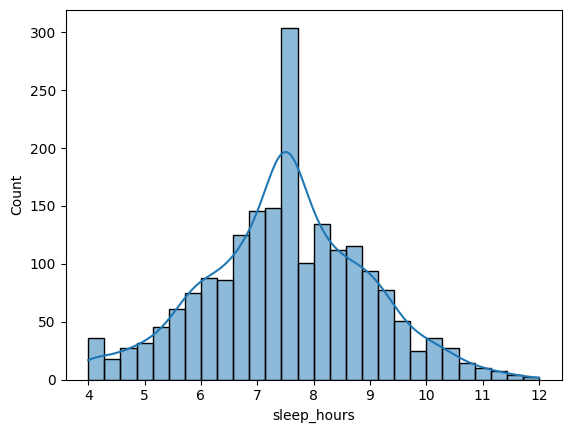

In [ ]:
# mengganti nilai null sleep hours dengan median
df['sleep_hours'].fillna(df['sleep_hours'].median(), inplace=True)

sns.histplot(df['sleep_hours'], kde=True)
plt.show()

In [ ]:
df['sleep_hours'].isnull().sum()

np.int64(0)

In [ ]:
df['sleep_hours'].mean()

np.float64(7.51225)

In [ ]:
df['smokes'].unique()
df['smokes'] = df['smokes'].replace({
    'yes': 1,
    'no': 0
})

df['smokes'] = df['smokes'].astype(int)

In [ ]:
df['gender'] = df['gender'].str.strip().str.upper().replace({'M': 1, 'F': 0})
df['gender'] = df['gender'].astype(int)


C:\Users\acer\AppData\Local\Temp\ipykernel_29384\1604760713.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['gender'] = df['gender'].str.strip().str.upper().replace({'M': 1, 'F': 0})


In [ ]:
df

,age,height_cm,weight_kg,heart_rate,blood_pressure,sleep_hours,nutrition_quality,activity_index,smokes,gender,is_fit
0,56,152,65,69.6,117.0,7.5,2.37,3.97,0,0,1
1,69,186,95,60.8,114.8,7.5,8.77,3.19,0,0,1
2,46,192,103,61.4,116.4,7.5,8.20,2.03,0,0,0
3,32,189,83,60.2,130.1,7.0,6.18,3.68,0,1,1
4,60,175,99,58.1,115.8,8.0,9.95,4.83,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...
1995,52,173,98,60.7,106.1,7.5,1.54,3.25,1,1,1
1996,61,186,74,51.4,123.8,9.4,8.63,3.15,0,1,1
1997,77,198,89,76.7,103.6,8.3,1.98,3.36,1,1,0
1998,62,190,63,80.7,115.9,6.7,9.21,2.39,1,0,0


#### Normalisasi 

In [ ]:
df.describe()

,age,height_cm,weight_kg,heart_rate,blood_pressure,sleep_hours,nutrition_quality,activity_index,smokes,gender,is_fit
count,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.0000,2000.000000
mean,49.114000,174.53300,83.540500,70.288600,119.908850,7.512250,5.035140,2.999040,0.450500,0.4850,0.399500
std,17.926564,14.37175,25.852534,11.846339,14.578032,1.440671,2.864156,1.136383,0.497668,0.4999,0.489918
min,18.000000,150.00000,30.000000,45.000000,90.000000,4.000000,0.000000,1.000000,0.000000,0.0000,0.000000
25%,34.000000,162.00000,64.000000,62.100000,109.700000,6.600000,2.547500,2.037500,0.000000,0.0000,0.000000
50%,49.000000,174.00000,83.000000,70.250000,120.000000,7.500000,5.065000,2.980000,0.000000,0.0000,0.000000
75%,65.000000,187.00000,102.000000,78.425000,129.800000,8.400000,7.470000,3.950000,1.000000,1.0000,1.000000
max,79.000000,199.00000,250.000000,118.600000,171.200000,12.000000,10.000000,4.990000,1.000000,1.0000,1.000000


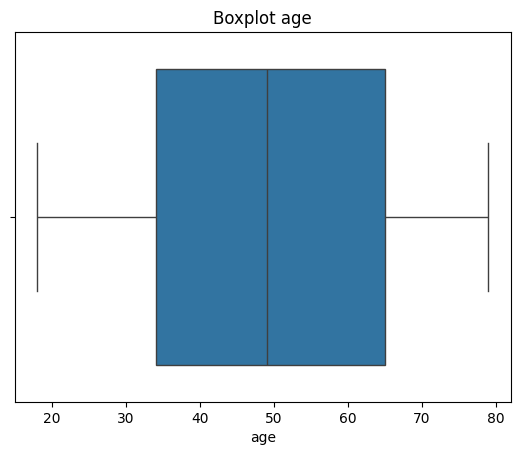

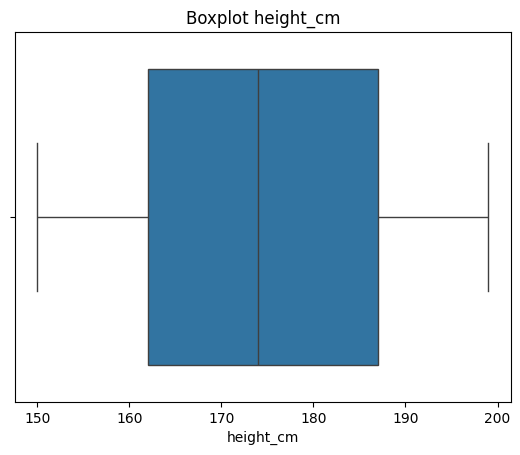

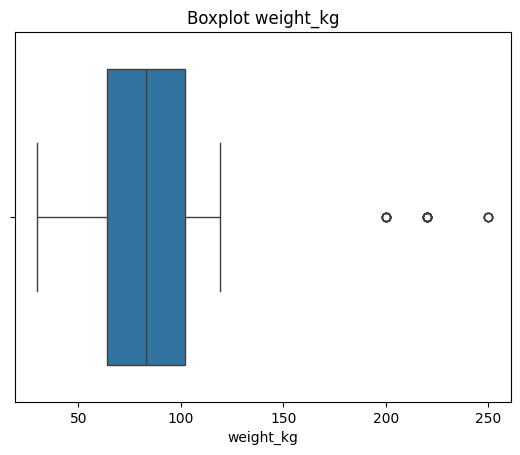

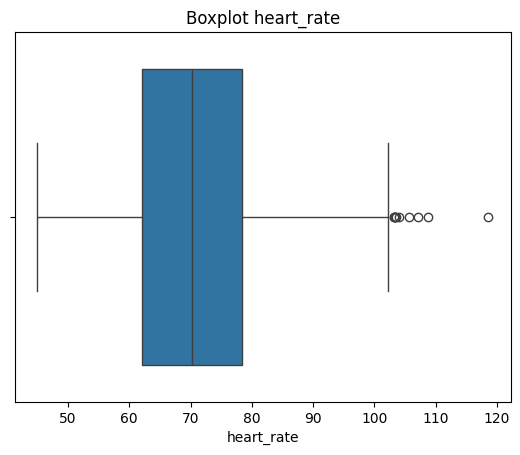

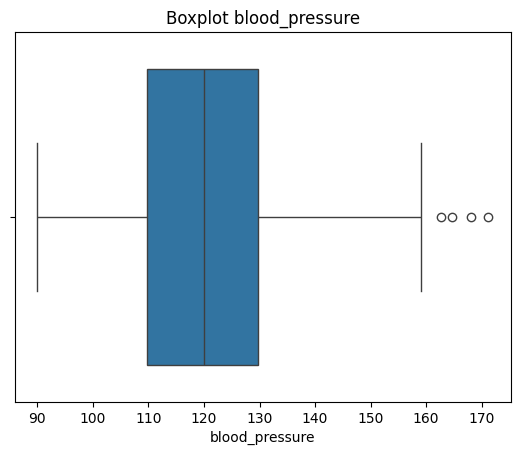

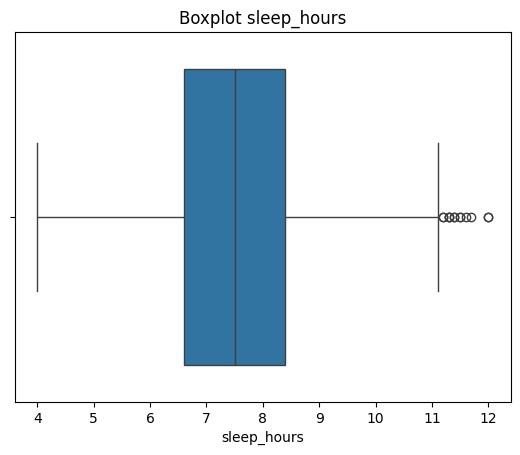

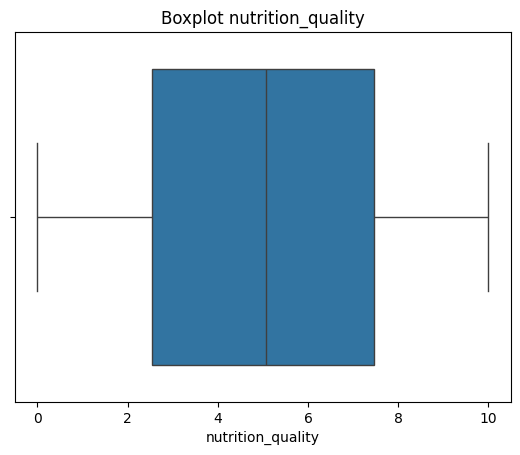

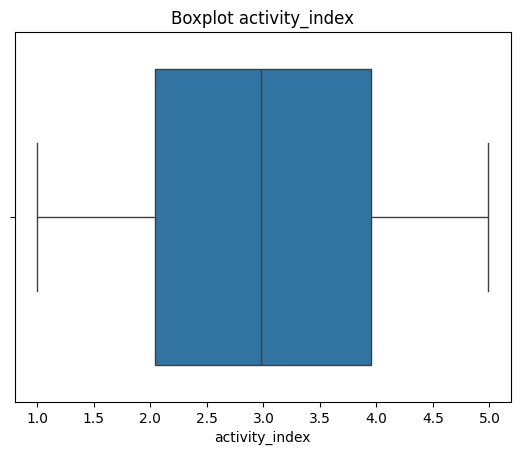

In [ ]:
for col in ['age','height_cm','weight_kg','heart_rate','blood_pressure','sleep_hours','nutrition_quality','activity_index']:
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot {col}')
    plt.show()


In [ ]:
from sklearn.preprocessing import RobustScaler

cols_to_scale = ['age','height_cm','weight_kg','heart_rate','blood_pressure',
                 'sleep_hours','nutrition_quality','activity_index']

scaler = RobustScaler()
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

df

,age,height_cm,weight_kg,heart_rate,blood_pressure,sleep_hours,nutrition_quality,activity_index,smokes,gender,is_fit
0,0.225806,-0.88,-0.473684,-0.039816,-0.149254,0.000000,-0.547486,0.517647,0,0,1
1,0.645161,0.48,0.315789,-0.578867,-0.258706,0.000000,0.752666,0.109804,0,0,1
2,-0.096774,0.72,0.526316,-0.542113,-0.179104,0.000000,0.636872,-0.496732,0,0,0
3,-0.548387,0.60,0.000000,-0.615620,0.502488,-0.277778,0.226511,0.366013,0,1,1
4,0.354839,0.04,0.421053,-0.744257,-0.208955,0.277778,0.992382,0.967320,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...
1995,0.096774,-0.04,0.394737,-0.584992,-0.691542,0.000000,-0.716100,0.141176,1,1,1
1996,0.387097,0.48,-0.236842,-1.154671,0.189055,1.055556,0.724225,0.088889,0,1,1
1997,0.903226,0.96,0.157895,0.395100,-0.815920,0.444444,-0.626714,0.198693,1,1,0
1998,0.419355,0.64,-0.526316,0.640123,-0.203980,-0.444444,0.842052,-0.308497,1,0,0


#### Splitting Data

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   age                2000 non-null   float64
 1   height_cm          2000 non-null   float64
 2   weight_kg          2000 non-null   float64
 3   heart_rate         2000 non-null   float64
 4   blood_pressure     2000 non-null   float64
 5   sleep_hours        2000 non-null   float64
 6   nutrition_quality  2000 non-null   float64
 7   activity_index     2000 non-null   float64
 8   smokes             2000 non-null   int64  
 9   gender             2000 non-null   int64  
 10  is_fit             2000 non-null   int64  
dtypes: float64(8), int64(3)
memory usage: 172.0 KB


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X = df.drop('is_fit', axis=1)  # semua kolom kecuali target
y = df['is_fit']               # kolom target

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,      # 20% untuk testing
    random_state=42,    # supaya hasilnya konsisten
    stratify=y          # menjaga proporsi kelas (penting untuk klasifikasi)
)

In [ ]:
print("Train set:", X_train.shape)
print("Test set:", X_test.shape)

Train set: (1600, 10)
Test set: (400, 10)


#### Modeling

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
# Inisialisasi model KNN
knn = KNeighborsClassifier(n_neighbors=5)  # kamu bisa ubah jumlah k-nya nanti

# Latih model
knn.fit(X_train, y_train)

# Prediksi
y_pred_knn = knn.predict(X_test)

# Evaluasi
print("=== K-Nearest Neighbors (KNN) ===")
print("Akurasi:", accuracy_score(y_test, y_pred_knn))
print("\nClassification Report:\n", classification_report(y_test, y_pred_knn))

=== K-Nearest Neighbors (KNN) ===
Akurasi: 0.7375

Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.82      0.79       240
           1       0.69      0.62      0.65       160

    accuracy                           0.74       400
   macro avg       0.73      0.72      0.72       400
weighted avg       0.73      0.74      0.73       400



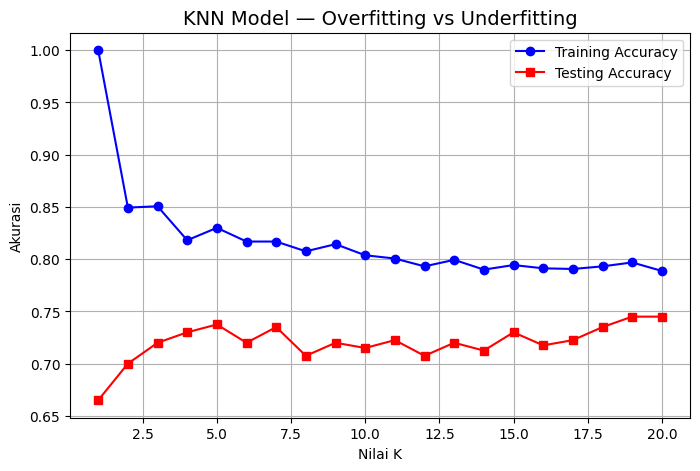

In [ ]:
train_scores = []
test_scores = []
k_values = range(1, 21)

# Uji K dari 1 sampai 20
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)

    # Akurasi di training dan testing
    train_scores.append(knn.score(X_train, y_train))
    test_scores.append(knn.score(X_test, y_test))

# Plot hasil
plt.figure(figsize=(8, 5))
plt.plot(k_values, train_scores, marker='o', label='Training Accuracy', color='blue')
plt.plot(k_values, test_scores, marker='s', label='Testing Accuracy', color='red')

plt.title('KNN Model — Overfitting vs Underfitting', fontsize=14)
plt.xlabel('Nilai K')
plt.ylabel('Akurasi')
plt.legend()
plt.grid(True)
plt.show()

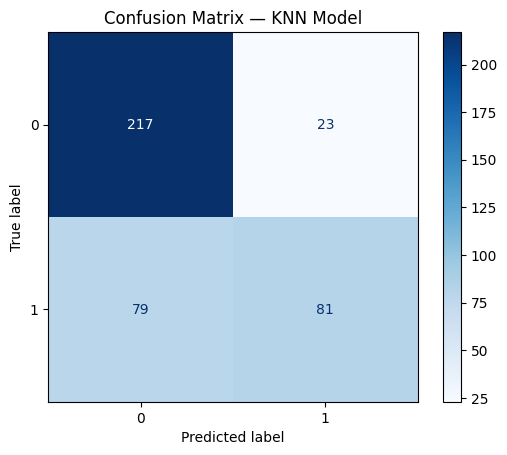

Classification Report — KNN Model:
              precision    recall  f1-score   support

           0       0.73      0.90      0.81       240
           1       0.78      0.51      0.61       160

    accuracy                           0.74       400
   macro avg       0.76      0.71      0.71       400
weighted avg       0.75      0.74      0.73       400



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# Prediksi dengan KNN 
y_pred_knn = knn.predict(X_test)

cm = confusion_matrix(y_test, y_pred_knn)

# Visualisad confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=knn.classes_)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix — KNN Model")
plt.show()

print("Classification Report — KNN Model:")
print(classification_report(y_test, y_pred_knn))


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

param_grid = {'n_neighbors': range(1, 31)}
grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)
grid.fit(X_train, y_train)

print("Best K:", grid.best_params_)
print("Best Score:", grid.best_score_)

Best K: {'n_neighbors': 29}
Best Score: 0.7768750000000001


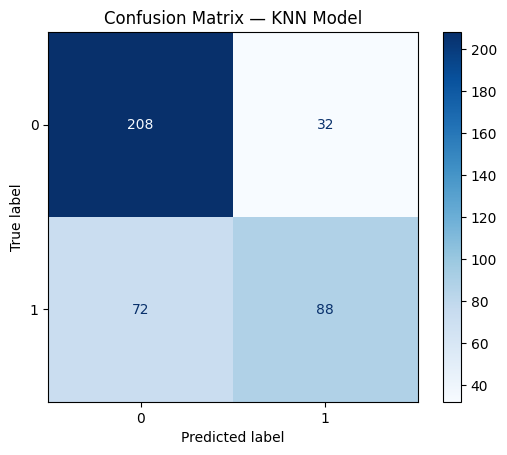

Classification Report — KNN Model:
              precision    recall  f1-score   support

           0       0.74      0.87      0.80       240
           1       0.73      0.55      0.63       160

    accuracy                           0.74       400
   macro avg       0.74      0.71      0.71       400
weighted avg       0.74      0.74      0.73       400



In [ ]:
knn = KNeighborsClassifier(n_neighbors=grid.best_params_['n_neighbors'])
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

cm = confusion_matrix(y_test, y_pred_knn)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=knn.classes_)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix — KNN Model")
plt.show()

print("Classification Report — KNN Model:")
print(classification_report(y_test, y_pred_knn))